# VGG16 + DenseNet121 Early Fusion — NTW Dataset — Image-Level

This notebook trains and evaluates **both early-fusion methods**:

1. **Concatenation fusion**
2. **Attention fusion**

Each method is trained separately and saved in its own folder. Outputs include:

- `.keras` models
- Model summaries
- Parameter counts
- Training history CSV and JSON
- Accuracy, loss, and AUC graphs
- Accuracy, precision, recall, specificity, F1-score, and ROC-AUC
- Classification reports
- Confusion matrices
- ROC curves
- NPZ prediction files
- Prediction CSV files
- Clean fusion Grad-CAM examples
- Final concatenation-versus-attention comparison

## Final training schedule

- Concatenation fusion: **35 total epochs**
- Attention fusion: **35 total epochs**
- Stage 1 frozen-backbone training: **10 epochs**
- Stage 2 partial fine-tuning: **25 epochs**
- Total per fusion model: **35 epochs**
- Total after both fusion models finish: **70 model-training epochs**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:

import json
import random
import shutil
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16, DenseNet121
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# CHANGE ONLY THESE THREE PATHS
ZIP_PATH = "/content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_image_level/VGG16_Denesenet_image_level_dataset_here/Parkinson_dataset_2.zip"
UNZIP_DIR = "/content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_image_level/VGG16_Denesenet_image_level_dataset_unzip_here"
SAVE_DIR = "/content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_image_level/VGG16_Denesenet_image_level_data_save_here_2"

IMG_SIZE = (224, 224)
BATCH_SIZE = 8

WARMUP_EPOCHS = 10
FINE_TUNE_EPOCHS = 25
EPOCHS_PER_FUSION_MODEL = WARMUP_EPOCHS + FINE_TUNE_EPOCHS
TOTAL_EPOCHS_FOR_BOTH_FUSIONS = EPOCHS_PER_FUSION_MODEL * 2
VGG_FINE_TUNE_LAST = 8
DENSENET_FINE_TUNE_LAST = 30

FUSION_METHODS = ["concatenation", "attention"]

Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)
print("Results folder:", SAVE_DIR)
print("Frozen warm-up epochs:", WARMUP_EPOCHS)
print("Fine-tuning epochs:", FINE_TUNE_EPOCHS)
print("Epochs per fusion model:", EPOCHS_PER_FUSION_MODEL)
print("Total epochs for both fusion models:", TOTAL_EPOCHS_FOR_BOTH_FUSIONS)


Results folder: /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_image_level/VGG16_Denesenet_image_level_data_save_here_2
Frozen warm-up epochs: 10
Fine-tuning epochs: 25
Epochs per fusion model: 35
Total epochs for both fusion models: 70


In [ ]:
# UNZIP DATASET AND BUILD METADATA
if not Path(ZIP_PATH).exists():
    raise FileNotFoundError(f"ZIP file not found: {ZIP_PATH}")

if Path(UNZIP_DIR).exists():
    shutil.rmtree(UNZIP_DIR)
Path(UNZIP_DIR).mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as archive:
    archive.extractall(UNZIP_DIR)

def find_dataset_root(root):
    root = Path(root)
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for candidate in candidates:
        if (candidate / "healthy_control").is_dir() and (candidate / "parkinson").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find a folder containing both healthy_control and parkinson."
    )

DATASET_ROOT = find_dataset_root(UNZIP_DIR)
print("Dataset root:", DATASET_ROOT)

valid_extensions = {".png", ".jpg", ".jpeg", ".bmp"}
class_mapping = {"healthy_control": 0, "parkinson": 1}

records = []

for class_name, label in class_mapping.items():
    for image_path in (DATASET_ROOT / class_name).rglob("*"):
        if image_path.is_file() and image_path.suffix.lower() in valid_extensions:
            records.append(
                {
                    "filepath": str(image_path),
                    "label": label,
                    "class_name": class_name,
                    "patient_id": image_path.parent.name,
                    "source_dataset": image_path.parent.parent.name,
                }
            )

df = pd.DataFrame(records).sort_values("filepath").reset_index(drop=True)

if df.empty:
    raise ValueError("No images were found.")

print("Total images:", len(df))
print("\nImages by class:")
print(df["class_name"].value_counts())

print("\nParticipants by class:")
print(df.groupby("class_name")["patient_id"].nunique())

print("\nImages by source dataset:")
print(df["source_dataset"].value_counts())

print("\nImages per participant:")
display(df.groupby("patient_id").size().describe().to_frame("images_per_participant"))

df.to_csv(Path(SAVE_DIR) / "NTW_complete_metadata.csv", index=False)

Dataset root: /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_image_level/VGG16_Denesenet_image_level_dataset_unzip_here/sagittal_images
Total images: 3320

Images by class:
class_name
parkinson          1880
healthy_control    1440
Name: count, dtype: int64

Participants by class:
class_name
healthy_control    36
parkinson          47
Name: patient_id, dtype: int64

Images by source dataset:
source_dataset
NEUROCON    1720
Tao_Wu      1600
Name: count, dtype: int64

Images per participant:


,images_per_participant
count,83.0
mean,40.0
std,0.0
min,40.0
25%,40.0
50%,40.0
75%,40.0
max,40.0


In [ ]:
# IMAGE-LEVEL 70/15/15 SPLIT
train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"],
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_df["label"],
)

for split_name, split_df in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Testing", test_df),
]:
    print(f"\n{split_name}: {len(split_df)} images")
    print(split_df["class_name"].value_counts())

train_df.to_csv(Path(SAVE_DIR) / "image_train_split.csv", index=False)
validation_df.to_csv(
    Path(SAVE_DIR) / "image_validation_split.csv",
    index=False,
)
test_df.to_csv(Path(SAVE_DIR) / "image_test_split.csv", index=False)


Training: 2324 images
class_name
parkinson          1316
healthy_control    1008
Name: count, dtype: int64

Validation: 498 images
class_name
parkinson          282
healthy_control    216
Name: count, dtype: int64

Testing: 498 images
class_name
parkinson          282
healthy_control    216
Name: count, dtype: int64


In [ ]:
# DUAL-INPUT TF.DATA PIPELINE
AUTOTUNE = tf.data.AUTOTUNE

augmentation = keras.Sequential(
    [
        layers.RandomRotation(0.04, fill_mode="nearest", seed=SEED),
        layers.RandomZoom(0.10, fill_mode="nearest", seed=SEED),
        layers.RandomTranslation(
            0.05,
            0.05,
            fill_mode="nearest",
            seed=SEED,
        ),
    ],
    name="augmentation",
)

def decode_dual_input(path, label, training=False):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    if training:
        image = augmentation(image, training=True)

    return {
        "vgg_input": vgg_preprocess(tf.identity(image)),
        "dense_input": dense_preprocess(tf.identity(image)),
    }, tf.cast(label, tf.float32)

def make_dataset(frame, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            frame["filepath"].astype(str).values,
            frame["label"].astype("float32").values,
        )
    )

    if training:
        dataset = dataset.shuffle(
            len(frame),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        lambda path, label: decode_dual_input(path, label, training),
        num_parallel_calls=AUTOTUNE,
    )

    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
validation_ds = make_dataset(validation_df, training=False)
test_ds = make_dataset(test_df, training=False)

print("TensorFlow datasets created.")

TensorFlow datasets created.


In [ ]:
# MODEL AND OUTPUT HELPERS
def create_result_folders(run_folder):
    folder_names = [
        "models",
        "summaries",
        "parameters",
        "histories",
        "graphs",
        "metrics",
        "classification_reports",
        "confusion_matrices",
        "roc_curves",
        "npz",
        "predictions",
        "gradcam",
    ]

    folders = {}
    for folder_name in folder_names:
        folders[folder_name] = Path(run_folder) / folder_name
        folders[folder_name].mkdir(parents=True, exist_ok=True)

    return folders

def build_model(fusion_type):
    vgg_input = keras.Input(
        shape=(*IMG_SIZE, 3),
        name="vgg_input",
    )
    dense_input = keras.Input(
        shape=(*IMG_SIZE, 3),
        name="dense_input",
    )

    vgg_backbone = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )
    dense_backbone = DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )

    vgg_backbone.trainable = False
    dense_backbone.trainable = False

    vgg_feature_map = vgg_backbone(vgg_input, training=False)
    dense_feature_map = dense_backbone(dense_input, training=False)

    vgg_vector = layers.GlobalAveragePooling2D(
        name="vgg_gap"
    )(vgg_feature_map)
    dense_vector = layers.GlobalAveragePooling2D(
        name="dense_gap"
    )(dense_feature_map)

    vgg_vector = layers.Dense(
        256,
        activation="relu",
        name="vgg_projection",
    )(vgg_vector)
    dense_vector = layers.Dense(
        256,
        activation="relu",
        name="dense_projection",
    )(dense_vector)

    if fusion_type == "concatenation":
        fused_vector = layers.Concatenate(
            name="fusion_concat"
        )([vgg_vector, dense_vector])
    else:
        vgg_token = layers.Reshape(
            (1, 256),
            name="vgg_token",
        )(vgg_vector)
        dense_token = layers.Reshape(
            (1, 256),
            name="dense_token",
        )(dense_vector)

        feature_stack = layers.Concatenate(
            axis=1,
            name="feature_stack",
        )([vgg_token, dense_token])

        attention_scores = layers.Dense(
            1,
            name="attention_score",
        )(feature_stack)

        attention_weights = layers.Softmax(
            axis=1,
            name="attention_weights",
        )(attention_scores)

        weighted_features = layers.Multiply(
            name="weighted_features",
        )([feature_stack, attention_weights])

        fused_vector = layers.Flatten(
            name="weighted_flatten",
        )(weighted_features)

    x = layers.Dense(
        256,
        activation="relu",
        name="fusion_dense",
    )(fused_vector)
    x = layers.Dropout(
        0.50,
        name="fusion_dropout",
    )(x)
    output = layers.Dense(
        1,
        activation="sigmoid",
        name="prediction",
    )(x)

    model = keras.Model(
        inputs={
            "vgg_input": vgg_input,
            "dense_input": dense_input,
        },
        outputs=output,
        name=f"VGG16_DenseNet121_{fusion_type}_NTW",
    )
    return model, vgg_backbone, dense_backbone

def compile_model(model, learning_rate):
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )

def locate_backbones(model):
    vgg_backbone = None
    dense_backbone = None

    for layer in model.layers:
        if isinstance(layer, keras.Model):
            if layer.name.startswith("vgg16"):
                vgg_backbone = layer
            elif layer.name.startswith("densenet"):
                dense_backbone = layer

    if vgg_backbone is None or dense_backbone is None:
        raise ValueError("Could not locate both backbones.")

    return vgg_backbone, dense_backbone

def save_summary_and_parameters(model, folders, file_prefix):
    summary_lines = []
    model.summary(print_fn=summary_lines.append)

    (
        folders["summaries"]
        / f"{file_prefix}_model_summary.txt"
    ).write_text(
        "\n".join(summary_lines),
        encoding="utf-8",
    )

    trainable_count = sum(
        int(tf.keras.backend.count_params(weight))
        for weight in model.trainable_weights
    )
    non_trainable_count = sum(
        int(tf.keras.backend.count_params(weight))
        for weight in model.non_trainable_weights
    )

    parameter_frame = pd.DataFrame(
        [
            {
                "model": model.name,
                "total_parameters": (
                    trainable_count + non_trainable_count
                ),
                "trainable_parameters": trainable_count,
                "non_trainable_parameters": non_trainable_count,
            }
        ]
    )

    display(parameter_frame)
    parameter_frame.to_csv(
        folders["parameters"]
        / f"{file_prefix}_parameter_counts.csv",
        index=False,
    )

def merge_histories(*history_objects):
    merged = {}

    for history_object in history_objects:
        for metric_name, values in history_object.history.items():
            merged.setdefault(metric_name, [])
            merged[metric_name].extend(
                [float(value) for value in values]
            )

    return merged

def save_history_and_graphs(
    history,
    folders,
    file_prefix,
    title_prefix,
):
    pd.DataFrame(history).to_csv(
        folders["histories"]
        / f"{file_prefix}_history.csv",
        index=False,
    )

    with open(
        folders["histories"]
        / f"{file_prefix}_history.json",
        "w",
        encoding="utf-8",
    ) as output_file:
        json.dump(history, output_file, indent=2)

    epochs = np.arange(1, len(history["loss"]) + 1)

    for metric_name, y_label, file_suffix in [
        ("accuracy", "Accuracy", "accuracy"),
        ("loss", "Binary Cross-Entropy Loss", "loss"),
        ("auc", "ROC-AUC", "auc"),
    ]:
        plt.figure(figsize=(9, 6))
        plt.plot(
            epochs,
            history[metric_name],
            linewidth=2,
            label=f"Training {y_label}",
        )
        plt.plot(
            epochs,
            history[f"val_{metric_name}"],
            linewidth=2,
            label=f"Validation {y_label}",
        )
        plt.axvline(
            WARMUP_EPOCHS,
            linestyle="--",
            label="Fine-Tuning Start",
        )
        plt.title(
            f"{title_prefix} {y_label}",
            fontsize=14,
            fontweight="bold",
        )
        plt.xlabel("Epoch")
        plt.ylabel(y_label)

        if metric_name in {"accuracy", "auc"}:
            plt.ylim(0, 1.02)

        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.savefig(
            folders["graphs"]
            / f"{file_prefix}_{file_suffix}.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

In [ ]:
# TRAIN ONE FUSION METHOD
def train_fusion_method(fusion_type):
    run_folder = Path(SAVE_DIR) / fusion_type
    folders = create_result_folders(run_folder)
    file_prefix = f"VGG16_DenseNet121_{fusion_type}_NTW"

    model, vgg_backbone, dense_backbone = build_model(
        fusion_type
    )

    # Stage 1: frozen warm-up
    compile_model(model, 1e-4)

    warmup_path = (
        folders["models"]
        / f"{file_prefix}_warmup_best.keras"
    )

    warmup_callbacks = [
        keras.callbacks.ModelCheckpoint(
            str(warmup_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

    warmup_history = model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=WARMUP_EPOCHS,
        callbacks=warmup_callbacks,
        verbose=1,
    )

    model = keras.models.load_model(warmup_path)
    vgg_backbone, dense_backbone = locate_backbones(model)

    # Stage 2: partial fine-tuning
    vgg_backbone.trainable = True
    dense_backbone.trainable = True

    for layer in vgg_backbone.layers[:-VGG_FINE_TUNE_LAST]:
        layer.trainable = False
    for layer in vgg_backbone.layers[-VGG_FINE_TUNE_LAST:]:
        layer.trainable = True

    for layer in dense_backbone.layers[:-DENSENET_FINE_TUNE_LAST]:
        layer.trainable = False
    for layer in dense_backbone.layers[-DENSENET_FINE_TUNE_LAST:]:
        layer.trainable = True

    compile_model(model, 5e-6)

    save_summary_and_parameters(
        model,
        folders,
        file_prefix,
    )

    best_path = (
        folders["models"]
        / f"{file_prefix}_best.keras"
    )

    fine_tune_callbacks = [
        keras.callbacks.ModelCheckpoint(
            str(best_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=4,
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.CSVLogger(
            str(
                folders["histories"]
                / f"{file_prefix}_training_log.csv"
            )
        ),
    ]

    fine_tune_history = model.fit(
        train_ds,
        validation_data=validation_ds,
        initial_epoch=WARMUP_EPOCHS,
        epochs=WARMUP_EPOCHS + FINE_TUNE_EPOCHS,
        callbacks=fine_tune_callbacks,
        verbose=1,
    )

    complete_history = merge_histories(
        warmup_history,
        fine_tune_history,
    )

    save_history_and_graphs(
        complete_history,
        folders,
        file_prefix,
        (
            "VGG16 + DenseNet121 NTW Dataset — "
            f"{fusion_type.title()}"
        ),
    )

    best_model = keras.models.load_model(best_path)
    return best_model, folders, file_prefix

In [ ]:
def save_evaluation_outputs(
    y_true,
    y_score,
    y_pred,
    gradcam_source,
    model,
    fusion_type,
    folders,
    file_prefix,
    **kwargs,
):
    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )
    tn, fp, fn, tp = matrix.ravel()

    metrics = {
        "Model": file_prefix,
        "Evaluation_Level": "Image-Level",
        "Fusion_Type": fusion_type,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "Specificity": (
            tn / (tn + fp)
            if (tn + fp)
            else np.nan
        ),
        "F1_Score": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            y_score,
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Evaluation_Samples": int(len(y_true)),
    }

    metrics_frame = pd.DataFrame([metrics])
    display(metrics_frame)
    metrics_frame.to_csv(
        folders["metrics"]
        / f"{file_prefix}_metrics.csv",
        index=False,
    )

    report = classification_report(
        y_true,
        y_pred,
        target_names=[
            "Healthy Control",
            "Parkinson",
        ],
        digits=4,
        zero_division=0,
    )
    print(report)

    (
        folders["classification_reports"]
        / f"{file_prefix}_classification_report.txt"
    ).write_text(
        report,
        encoding="utf-8",
    )

    plt.figure(figsize=(6, 5))
    plt.imshow(matrix, cmap="Blues")
    plt.title(
        "VGG16 + DenseNet121 NTW Dataset\n"
        f"{fusion_type.title()} Image-Level "
        "Confusion Matrix",
        fontweight="bold",
    )
    plt.xticks(
        [0, 1],
        ["Healthy Control", "Parkinson"],
    )
    plt.yticks(
        [0, 1],
        ["Healthy Control", "Parkinson"],
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    threshold = matrix.max() / 2
    for row in range(2):
        for column in range(2):
            plt.text(
                column,
                row,
                matrix[row, column],
                ha="center",
                va="center",
                fontsize=15,
                fontweight="bold",
                color=(
                    "white"
                    if matrix[row, column] > threshold
                    else "black"
                ),
            )

    plt.tight_layout()
    plt.savefig(
        folders["confusion_matrices"]
        / f"{file_prefix}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_score,
    )

    plt.figure(figsize=(7, 6))
    plt.plot(
        fpr,
        tpr,
        linewidth=2.5,
        label=(
            f"{fusion_type.title()} "
            f"(AUC={metrics['ROC_AUC']:.4f})"
        ),
    )
    plt.plot(
        [0, 1],
        [0, 1],
        "--",
        label="Random Classifier",
    )
    plt.title(
        "VGG16 + DenseNet121 NTW Dataset\n"
        f"{fusion_type.title()} Image-Level ROC Curve",
        fontweight="bold",
    )
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(alpha=0.25)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(
        folders["roc_curves"]
        / f"{file_prefix}_roc_curve.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    np.savez_compressed(
        folders["npz"]
        / f"{file_prefix}_predictions_roc.npz",
        y_true=y_true,
        y_score=y_score,
        y_pred=y_pred,
        fpr=fpr,
        tpr=tpr,
        thresholds=thresholds,
        roc_auc=np.array([metrics["ROC_AUC"]]),
    )

    generate_clean_gradcams(
        model,
        fusion_type,
        gradcam_source,
        folders,
        file_prefix,
        **kwargs,
    )

    return metrics

In [ ]:
def evaluate_model(model, fusion_type, folders, file_prefix, **kwargs):
    probabilities = model.predict(
        test_ds,
        verbose=1,
    ).ravel()

    prediction_frame = test_df[
        [
            "filepath",
            "patient_id",
            "source_dataset",
            "class_name",
            "label",
        ]
    ].copy()

    prediction_frame["probability_parkinson"] = probabilities
    prediction_frame["predicted_label"] = (
        probabilities >= 0.5
    ).astype(int)

    prediction_frame.to_csv(
        folders["predictions"]
        / f"{file_prefix}_predictions.csv",
        index=False,
    )

    y_true = prediction_frame["label"].to_numpy(dtype=int)
    y_score = prediction_frame[
        "probability_parkinson"
    ].to_numpy(dtype=float)
    y_pred = prediction_frame[
        "predicted_label"
    ].to_numpy(dtype=int)

    gradcam_source = prediction_frame[
        prediction_frame["label"]
        == prediction_frame["predicted_label"]
    ].copy()

    return save_evaluation_outputs(
        y_true,
        y_score,
        y_pred,
        gradcam_source,
        model,
        fusion_type,
        folders,
        file_prefix,
        **kwargs,
    )

In [ ]:
def create_brain_mask(
    image_rgb,
    threshold_percentile=18,
    face_neck_crop_ratio=0.78,
    border_crop_ratio=0.02,
    closing_kernel_size=(11, 11),
    erosion_size_factor=0.055,
    gaussian_blur_kernel=(15, 15),
):
    """Create a conservative soft intracranial ROI for sagittal T1 slices.

    This is a visualization mask, not a clinical brain segmentation.  It
    removes black background, most skull-edge responses, and the inferior
    face/neck region that otherwise dominates Grad-CAM overlays.

    Args:
        image_rgb (np.ndarray): The RGB image array.
        threshold_percentile (int): Percentile to use for thresholding non-zero pixels.
        face_neck_crop_ratio (float): Ratio to crop from the bottom to exclude face/neck.
        border_crop_ratio (float): Ratio to crop from left/right borders.
        closing_kernel_size (tuple): Kernel size for morphological closing operation.
        erosion_size_factor (float): Factor to determine erosion kernel size based on image dimensions.
        gaussian_blur_kernel (tuple): Kernel size for Gaussian blur.

    Returns:
        np.ndarray: The brain mask as a float32 array.
    """
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    height, width = gray.shape

    nonzero = gray[gray > 0]
    if nonzero.size == 0:
        return np.ones_like(gray, dtype=np.float32)

    # Use percentile to find a robust threshold for foreground
    threshold = max(5.0, float(np.percentile(nonzero, threshold_percentile)))
    foreground = (gray >= threshold).astype(np.uint8) * 255

    # Exclude the inferior face/neck and extreme image borders.
    foreground[int(face_neck_crop_ratio * height):, :] = 0
    foreground[:, :max(1, int(border_crop_ratio * width))] = 0
    foreground[:, int((1 - border_crop_ratio) * width):] = 0

    # Morphological closing to fill small holes
    foreground = cv2.morphologyEx(
        foreground,
        cv2.MORPH_CLOSE,
        np.ones(closing_kernel_size, np.uint8),
        iterations=2,
    )

    # Find connected components to isolate the main brain region
    count, labels, stats, _ = cv2.connectedComponentsWithStats(
        foreground,
        connectivity=8,
    )
    if count <= 1:
        return np.ones_like(gray, dtype=np.float32)

    # Select the largest plausible superior component as the brain
    candidates = []
    for component in range(1, count):
        x, y, w, h, area = stats[component]
        center_y = y + h / 2.0
        # Filter components by size and vertical position to exclude non-brain regions
        if area >= 0.02 * height * width and center_y < 0.62 * height:
            candidates.append((area, component))
    component = max(candidates)[1] if candidates else 1 + np.argmax(
        stats[1:, cv2.CC_STAT_AREA]
    )
    mask = (labels == component).astype(np.uint8) * 255

    # Erosion suppresses skull/scalp-edge activation; blur gives a soft edge.
    erosion_size = max(7, int(round(min(height, width) * erosion_size_factor)))
    if erosion_size % 2 == 0:
        erosion_size += 1
    mask = cv2.erode(
        mask,
        cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (erosion_size, erosion_size),
        ),
        iterations=1,
    )
    mask = cv2.GaussianBlur(mask.astype(np.float32) / 255.0, gaussian_blur_kernel, 0)
    return np.clip(mask, 0.0, 1.0)


def get_branch_heatmaps(
    model,
    fusion_type,
    image_path,
):
    """Compute fusion Grad-CAM from the final spatial backbone maps.

    VGG16 and DenseNet121 both return 7x7 convolutional feature maps when
    include_top=False.  These tensors feed the GAP and fusion layers directly,
    so their gradients are connected for both concatenation and attention.
    This avoids fragile nested Functional models and Keras input-name warnings.
    """
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(image_rgb, IMG_SIZE)
    raw_batch = np.expand_dims(resized.astype(np.float32), axis=0)
    vgg_batch = vgg_preprocess(raw_batch.copy())
    dense_batch = dense_preprocess(raw_batch.copy())

    vgg_backbone, dense_backbone = locate_backbones(model)

    with tf.GradientTape(persistent=True) as tape:
        # These are the last spatial convolutional maps used by the classifier.
        vgg_feature_map = vgg_backbone(vgg_batch, training=False)
        dense_feature_map = dense_backbone(dense_batch, training=False)
        tape.watch(vgg_feature_map)
        tape.watch(dense_feature_map)

        logit, probability = forward_fusion_head(
            model,
            fusion_type,
            vgg_feature_map,
            dense_feature_map,
        )
        # FIX: use the logit (unsaturated) for the Grad-CAM target score.
        target_score = tf.reduce_sum(logit[:, 0])

    vgg_gradients = tape.gradient(target_score, vgg_feature_map)
    dense_gradients = tape.gradient(target_score, dense_feature_map)
    del tape

    def make_heatmap(feature_map, gradients):
        # Gradients are guaranteed by the direct GAP/fusion connection. This
        # fallback prevents an optional visualization from stopping evaluation
        # if a future Keras version behaves differently.
        if gradients is None:
            return np.zeros(feature_map.shape[1:3], dtype=np.float32)

        feature_map = tf.cast(feature_map, tf.float32)
        gradients = tf.cast(gradients, tf.float32)
        channel_weights = tf.reduce_mean(gradients, axis=(0, 1, 2))
        heatmap = tf.reduce_sum(feature_map[0] * channel_weights, axis=-1)
        heatmap = tf.nn.relu(heatmap)
        maximum = tf.reduce_max(heatmap)
        heatmap = tf.where(
            maximum > 0,
            heatmap / (maximum + tf.keras.backend.epsilon()),
            tf.zeros_like(heatmap),
        )
        heatmap = tf.where(
            tf.math.is_finite(heatmap),
            heatmap,
            tf.zeros_like(heatmap),
        )
        return heatmap.numpy().astype(np.float32)

    return (
        resized,
        make_heatmap(vgg_feature_map, vgg_gradients),
        make_heatmap(dense_feature_map, dense_gradients),
        float(probability.numpy()[0, 0]),
    )

def save_clean_fusion_gradcam(
    model,
    fusion_type,
    image_path,
    output_path,
    title,
    threshold_percentile=18,
    face_neck_crop_ratio=0.78,
    border_crop_ratio=0.02,
    closing_kernel_size=(11, 11),
    erosion_size_factor=0.055,
    gaussian_blur_kernel=(15, 15),
):
    resized, vgg_heatmap, dense_heatmap, probability = get_branch_heatmaps(
        model,
        fusion_type,
        image_path,
    )
    # Pass parameters to create_brain_mask for more control
    brain_mask = create_brain_mask(
        resized,
        threshold_percentile=threshold_percentile,
        face_neck_crop_ratio=face_neck_crop_ratio,
        border_crop_ratio=border_crop_ratio,
        closing_kernel_size=closing_kernel_size,
        erosion_size_factor=erosion_size_factor,
        gaussian_blur_kernel=gaussian_blur_kernel,
    )

    def resize_and_clean(heatmap):
        heatmap = cv2.resize(
            heatmap,
            IMG_SIZE,
            interpolation=cv2.INTER_CUBIC,
        )
        heatmap = np.nan_to_num(heatmap, nan=0.0, posinf=0.0, neginf=0.0)
        heatmap = np.maximum(heatmap, 0.0) * brain_mask
        maximum = float(heatmap.max())
        return heatmap / maximum if maximum > 0 else heatmap

    vgg_heatmap = resize_and_clean(vgg_heatmap)
    dense_heatmap = resize_and_clean(dense_heatmap)

    # Combine evidence from both branches. The gradients already encode each
    # branch's contribution to the selected fusion model prediction.
    fused_heatmap = 0.5 * vgg_heatmap + 0.5 * dense_heatmap
    positive = fused_heatmap[fused_heatmap > 0]
    if positive.size:
        low = float(np.percentile(positive, 55))
        high = float(np.percentile(positive, 99))
        if high > low:
            fused_heatmap = np.clip(
                (fused_heatmap - low) / (high - low),
                0.0,
                1.0,
            )
    fused_heatmap = cv2.GaussianBlur(fused_heatmap, (9, 9), 0)
    fused_heatmap = np.clip(fused_heatmap * brain_mask, 0.0, 1.0)

    colored = cv2.applyColorMap(
        np.uint8(255 * fused_heatmap),
        cv2.COLORMAP_JET,
    )
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB).astype(np.float32)
    original = resized.astype(np.float32)

    # Continuous alpha avoids the hard-edged artificial blobs in the earlier
    # figure and leaves low-activation anatomy visible.
    alpha = (0.62 * np.power(fused_heatmap, 0.75) * brain_mask)[..., None]
    overlay = np.clip(
        original * (1.0 - alpha) + colored * alpha,
        0,
        255,
    ).astype(np.uint8)

    predicted_class = "Parkinson" if probability >= 0.5 else "Healthy Control"
    probability_text = (
        ">0.9999" if probability > 0.9999
        else "<0.0001" if probability < 0.0001
        else f"{probability:.4f}"
    )

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
    axes[0].imshow(resized)
    axes[0].set_title("Original T1-weighted MRI")
    axes[1].imshow(resized, cmap="gray")
    axes[1].imshow(
        fused_heatmap,
        cmap="jet",
        vmin=0,
        vmax=1,
        alpha=np.clip(fused_heatmap * 0.90, 0, 0.90),
    )
    axes[1].set_title("Fused Grad-CAM")
    axes[2].imshow(overlay)
    axes[2].set_title(
        f"Overlay | Predicted: {predicted_class}\n"
        f"PD probability: {probability_text}"
    )
    for axis in axes:
        axis.axis("off")
    fig.suptitle(title, fontsize=14, fontweight="bold", y=0.98)
    plt.tight_layout(rect=(0, 0, 1, 0.94))
    plt.savefig(
        output_path,
        dpi=400,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()
    plt.close(fig)

def generate_clean_gradcams(
    model,
    fusion_type,
    prediction_frame,
    folders,
    file_prefix,
    threshold_percentile=18,
    face_neck_crop_ratio=0.78,
    border_crop_ratio=0.02,
    closing_kernel_size=(11, 11),
    erosion_size_factor=0.055,
    gaussian_blur_kernel=(15, 15),
):
    healthy_examples = (
        prediction_frame[
            prediction_frame["label"] == 0
        ]
        .sort_values(
            "probability_parkinson",
            ascending=True,
        )
        .head(1)
    )

    parkinson_examples = (
        prediction_frame[
            prediction_frame["label"] == 1
        ]
        .sort_values(
            "probability_parkinson",
            ascending=False,
        )
        .head(3)
    )

    selected_examples = pd.concat(
        [
            healthy_examples,
            parkinson_examples,
        ],
        ignore_index=True,
    )

    records = []

    for index, row in selected_examples.iterrows():
        class_title = (
            "Healthy Control"
            if row["label"] == 0
            else "Parkinson"
        )

        output_path = (
            folders["gradcam"]
            / (
                f"{file_prefix}_"
                f"{class_title.replace(' ', '_')}_"
                f"{index + 1}.png"
            )
        )

        save_clean_fusion_gradcam(
            model=model,
            fusion_type=fusion_type,
            image_path=row["filepath"],
            output_path=output_path,
            title=(
                "VGG16 + DenseNet121 NTW Dataset — "
                f"{fusion_type.title()} — "
                f"{class_title}"
            ),
            threshold_percentile=threshold_percentile,
            face_neck_crop_ratio=face_neck_crop_ratio,
            border_crop_ratio=border_crop_ratio,
            closing_kernel_size=closing_kernel_size,
            erosion_size_factor=erosion_size_factor,
            gaussian_blur_kernel=gaussian_blur_kernel,
        )

        records.append(
            {
                "filepath": row["filepath"],
                "patient_id": row["patient_id"],
                "true_class": row["class_name"],
                "probability_parkinson": (
                    row["probability_parkinson"]
                ),
                "output_file": str(output_path),
            }
        )

    pd.DataFrame(records).to_csv(
        folders["gradcam"]
        / f"{file_prefix}_gradcam_examples.csv",
        index=False,
    )


In [ ]:
def forward_fusion_head(model, fusion_type, vgg_feature_map, dense_feature_map):
    # Extract layers from the existing model
    vgg_gap = model.get_layer("vgg_gap")
    dense_gap = model.get_layer("dense_gap")
    vgg_projection = model.get_layer("vgg_projection")
    dense_projection = model.get_layer("dense_projection")

    vgg_vector = vgg_projection(vgg_gap(vgg_feature_map))
    dense_vector = dense_projection(dense_gap(dense_feature_map))

    if fusion_type == "concatenation":
        fused_vector = model.get_layer("fusion_concat")([vgg_vector, dense_vector])
    else:
        vgg_token = model.get_layer("vgg_token")(vgg_vector)
        dense_token = model.get_layer("dense_token")(dense_vector)
        feature_stack = model.get_layer("feature_stack")([vgg_token, dense_token])
        attention_scores = model.get_layer("attention_score")(feature_stack)
        attention_weights = model.get_layer("attention_weights")(attention_scores)
        weighted_features = model.get_layer("weighted_features")([feature_stack, attention_weights])
        fused_vector = model.get_layer("weighted_flatten")(weighted_features)

    x = model.get_layer("fusion_dense")(fused_vector)
    x = model.get_layer("fusion_dropout")(x, training=False)
    prediction_layer = model.get_layer("prediction")
    # FIX: return the pre-sigmoid logit (not the sigmoid probability) for
    # Grad-CAM gradients. At high-confidence predictions (prob > 0.999 or
    # < 0.001) the sigmoid saturates and its gradient collapses to ~0,
    # producing a blank all-zero Grad-CAM heatmap. The logit never
    # saturates, so gradients stay informative at any confidence level.
    logit = tf.matmul(x, prediction_layer.kernel) + prediction_layer.bias
    probability = tf.nn.sigmoid(logit)
    return logit, probability


Training VGG16 + DenseNet121 Concatenation Fusion
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5506 - auc: 0.5584 - loss: 0.9283
Epoch 1: val_auc improved from None to 0.76181, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_image_level/VGG16_Denesenet_image_level_data_save_here_2/concatenation/models/VGG16_DenseNet121_concatenation_NTW_warmup_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_image_level/VGG16_Denesenet_image_level_data_save_here_2/concatenation/models/VGG16_DenseNet121_concatenation_NTW_warmup_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 86s 188ms/step - accuracy: 0.5697 - auc: 0.5847 - loss: 0.8060 - val_accuracy: 0.6908 - val_auc: 0.7618 - val_loss: 0.5780 - learning_rate: 1.00

,model,total_parameters,trainable_parameters,non_trainable_parameters
0,VGG16_DenseNet121_concatenation_NTW,22277505,14145921,8131584


Epoch 11/35
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.7386 - auc: 0.8244 - loss: 0.5078
Epoch 11: val_auc improved from None to 0.87498, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_image_level/VGG16_Denesenet_image_level_data_save_here_2/concatenation/models/VGG16_DenseNet121_concatenation_NTW_best.keras

Epoch 11: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_image_level/VGG16_Denesenet_image_level_data_save_here_2/concatenation/models/VGG16_DenseNet121_concatenation_NTW_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 105s 219ms/step - accuracy: 0.7461 - auc: 0.8331 - loss: 0.4920 - val_accuracy: 0.7771 - val_auc: 0.8750 - val_loss: 0.4741 - learning_rate: 5.0000e-06
Epoch 12/35
289/291 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8020 - auc: 0.8890 - loss: 0.4218
Epoch 12: val_auc improved from 0.87498 to 0.89259, s

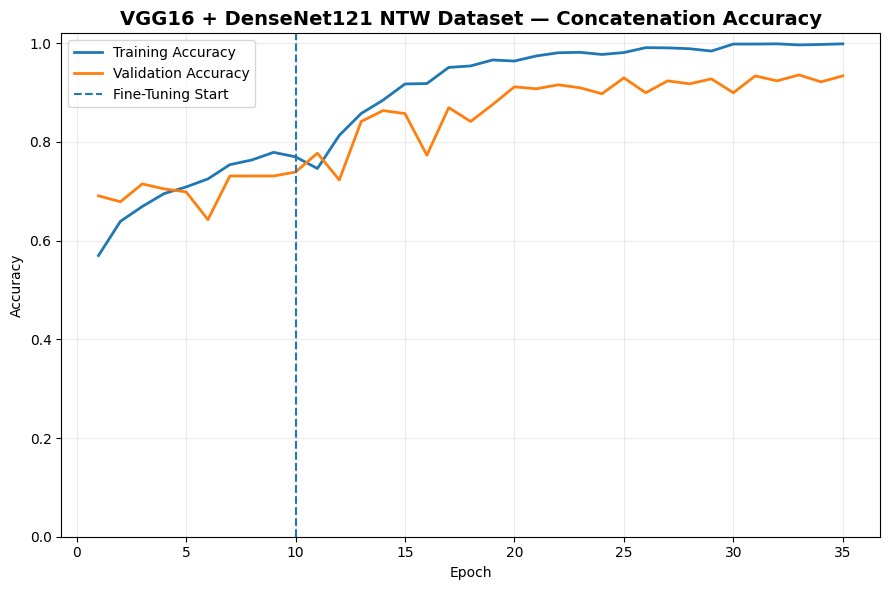

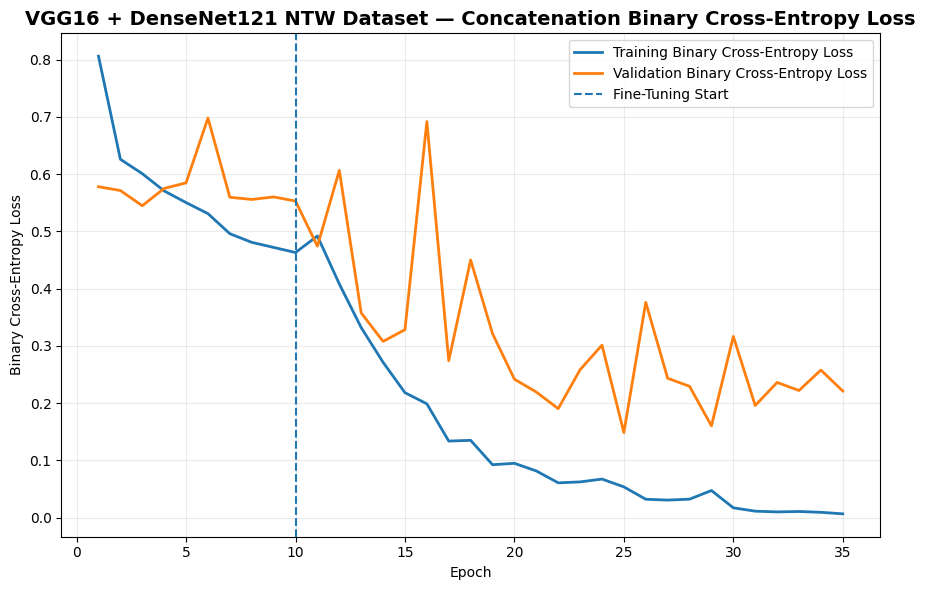

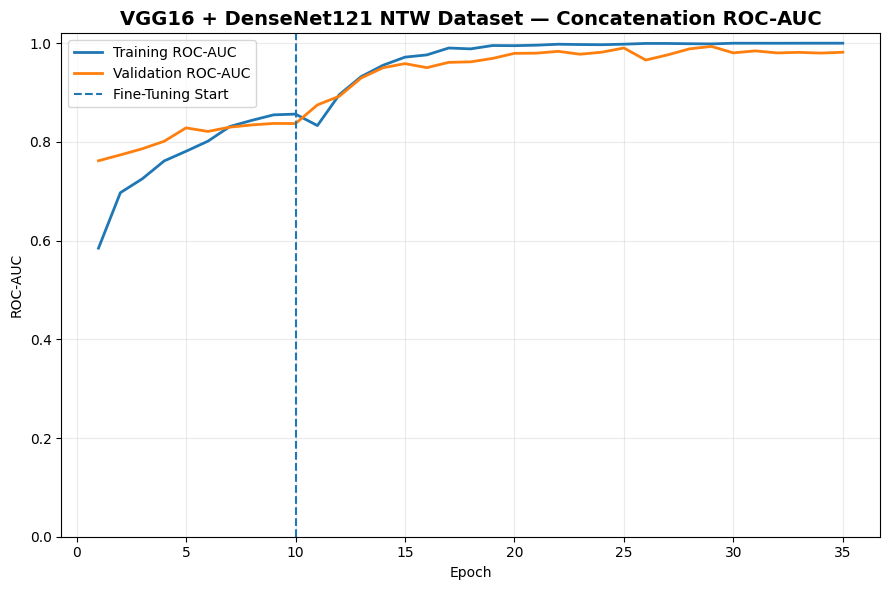

63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 205ms/step


,Model,Evaluation_Level,Fusion_Type,Accuracy,Precision,Recall,Specificity,F1_Score,ROC_AUC,TN,FP,FN,TP,Evaluation_Samples
0,VGG16_DenseNet121_concatenation_NTW,Image-Level,concatenation,0.939759,0.906452,0.996454,0.865741,0.949324,0.994205,187,29,1,281,498


                 precision    recall  f1-score   support

Healthy Control     0.9947    0.8657    0.9257       216
      Parkinson     0.9065    0.9965    0.9493       282

       accuracy                         0.9398       498
      macro avg     0.9506    0.9311    0.9375       498
   weighted avg     0.9447    0.9398    0.9391       498



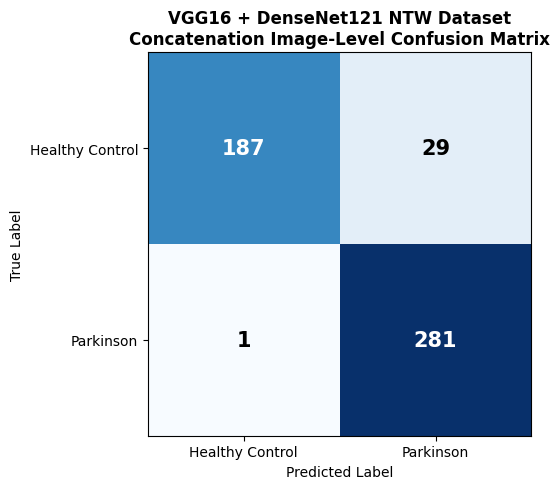

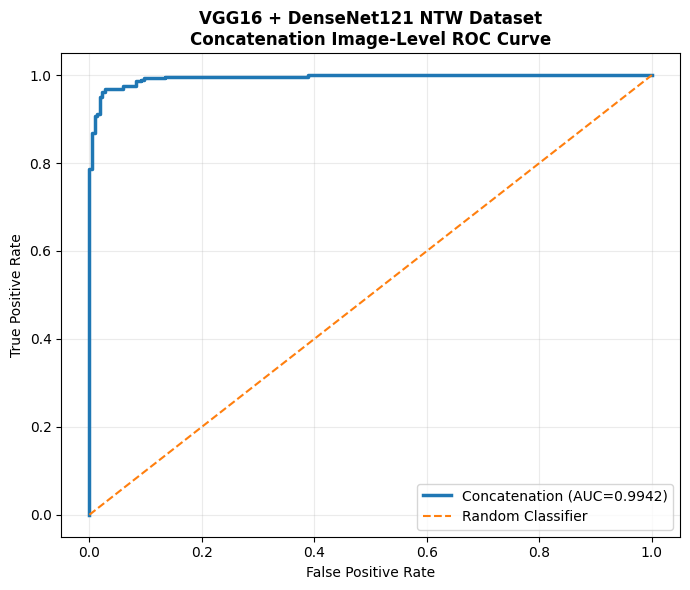

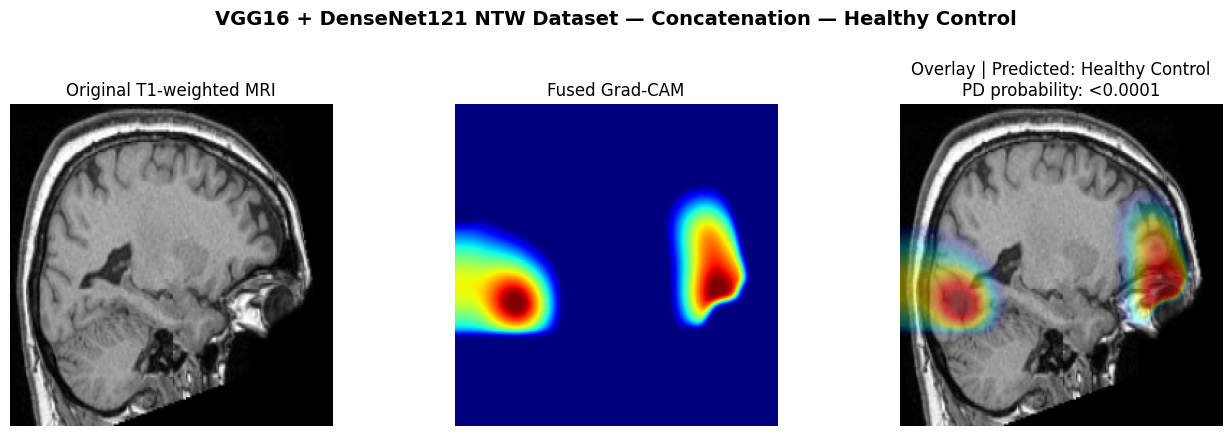

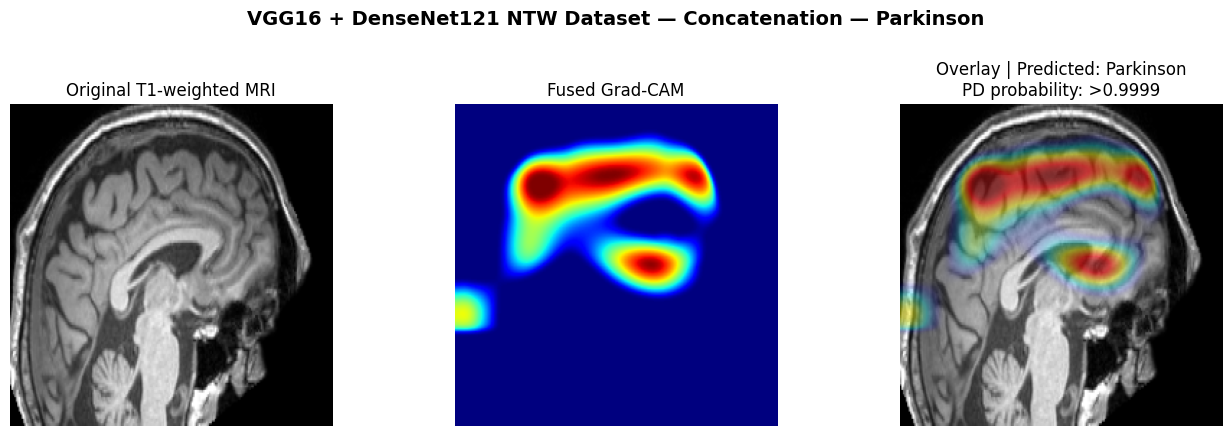

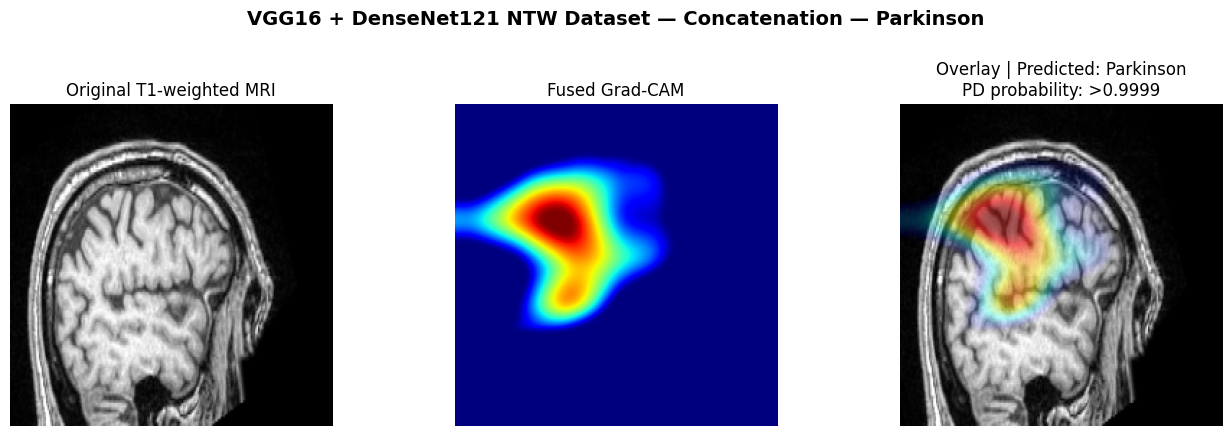

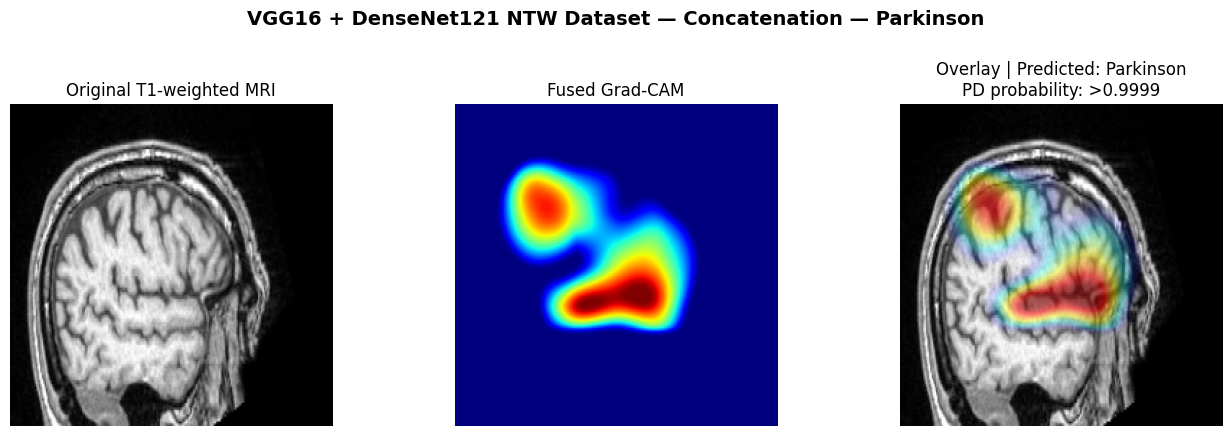


Training VGG16 + DenseNet121 Attention Fusion
Epoch 1/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5373 - auc: 0.5210 - loss: 0.7386
Epoch 1: val_auc improved from None to 0.62052, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_image_level/VGG16_Denesenet_image_level_data_save_here_2/attention/models/VGG16_DenseNet121_attention_NTW_warmup_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_image_level/VGG16_Denesenet_image_level_data_save_here_2/attention/models/VGG16_DenseNet121_attention_NTW_warmup_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 73s 163ms/step - accuracy: 0.5628 - auc: 0.5559 - loss: 0.7045 - val_accuracy: 0.6124 - val_auc: 0.6205 - val_loss: 0.6608 - learning_rate: 1.0000e-04
Epoch 2/10
289/291 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5989 - auc: 0.6303 - loss: 0.6626
Epoch 2: val_a

,model,total_parameters,trainable_parameters,non_trainable_parameters
0,VGG16_DenseNet121_attention_NTW,22277762,14146178,8131584


Epoch 11/35
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6781 - auc: 0.7457 - loss: 0.5910
Epoch 11: val_auc improved from None to 0.75800, saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_image_level/VGG16_Denesenet_image_level_data_save_here_2/attention/models/VGG16_DenseNet121_attention_NTW_best.keras

Epoch 11: finished saving model to /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_image_level/VGG16_Denesenet_image_level_data_save_here_2/attention/models/VGG16_DenseNet121_attention_NTW_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 102s 214ms/step - accuracy: 0.6988 - auc: 0.7616 - loss: 0.5751 - val_accuracy: 0.6847 - val_auc: 0.7580 - val_loss: 0.6013 - learning_rate: 5.0000e-06
Epoch 12/35
290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6945 - auc: 0.7642 - loss: 0.5674
Epoch 12: val_auc improved from 0.75800 to 0.75834, saving model to /

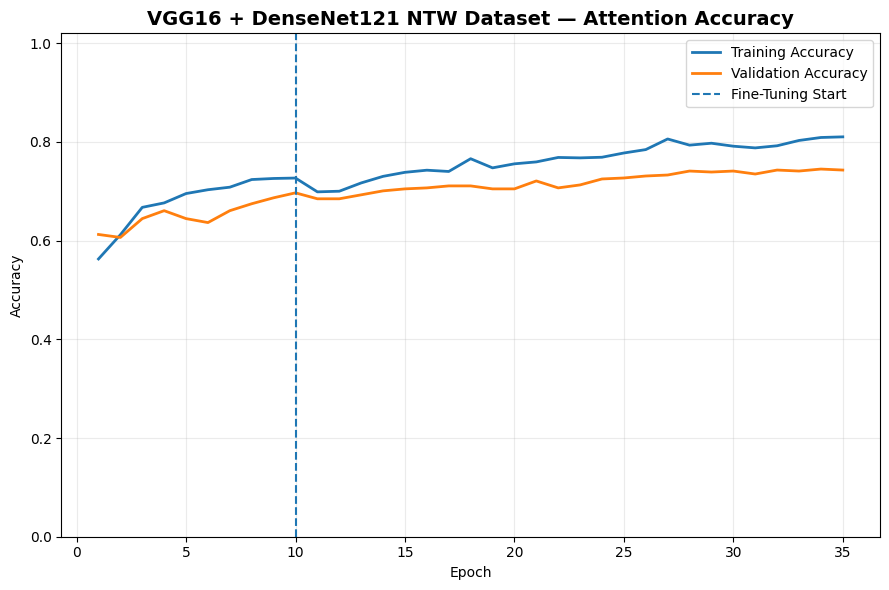

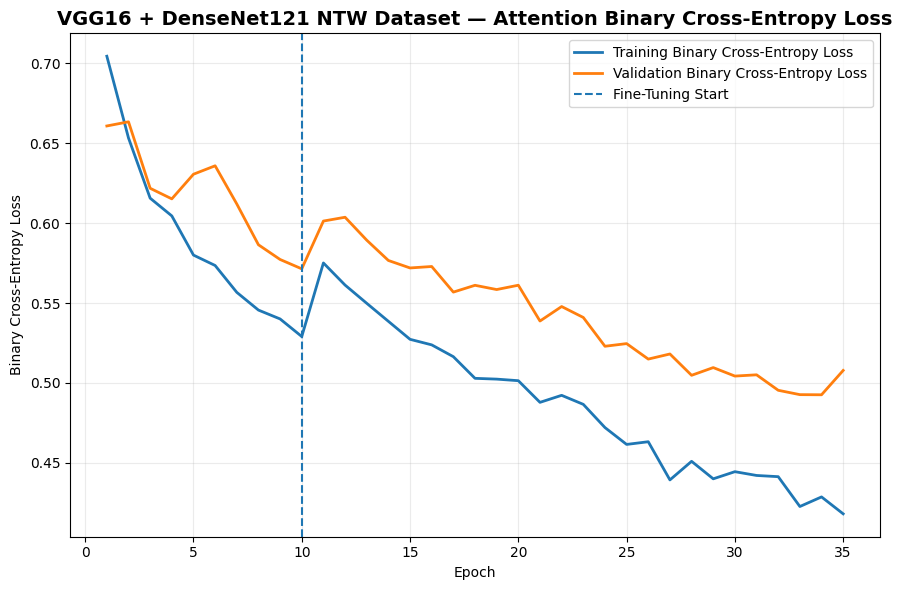

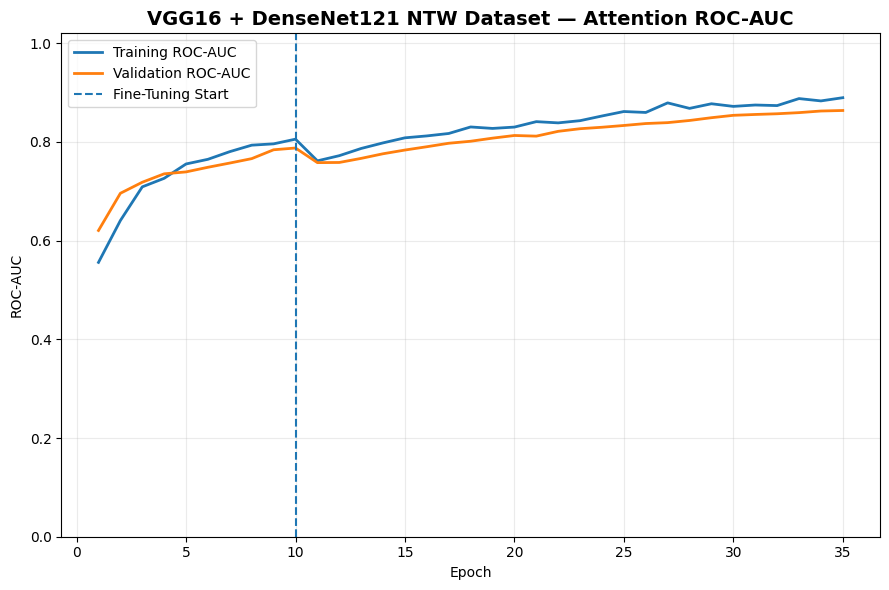

63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 206ms/step


,Model,Evaluation_Level,Fusion_Type,Accuracy,Precision,Recall,Specificity,F1_Score,ROC_AUC,TN,FP,FN,TP,Evaluation_Samples
0,VGG16_DenseNet121_attention_NTW,Image-Level,attention,0.748996,0.703896,0.960993,0.472222,0.812594,0.892419,102,114,11,271,498


                 precision    recall  f1-score   support

Healthy Control     0.9027    0.4722    0.6201       216
      Parkinson     0.7039    0.9610    0.8126       282

       accuracy                         0.7490       498
      macro avg     0.8033    0.7166    0.7163       498
   weighted avg     0.7901    0.7490    0.7291       498



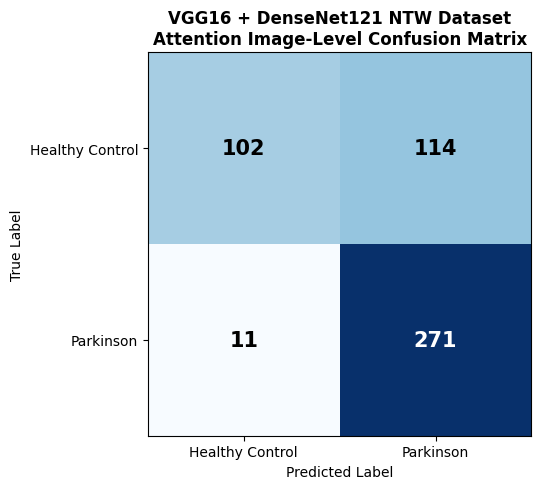

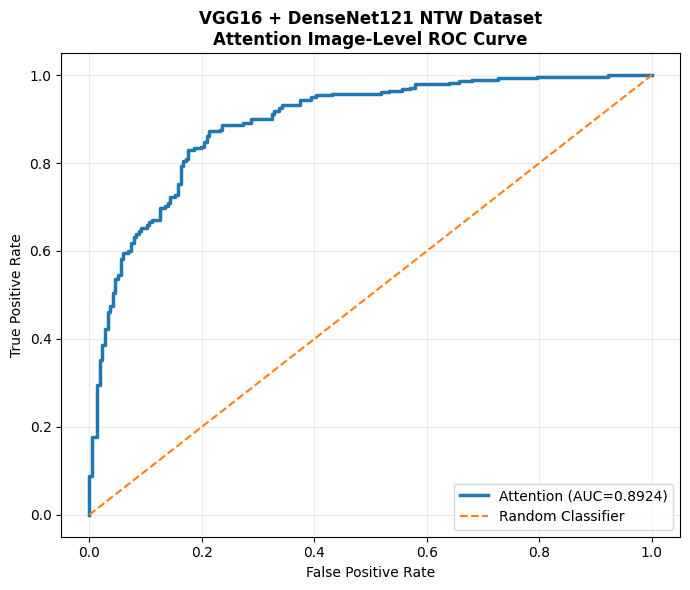

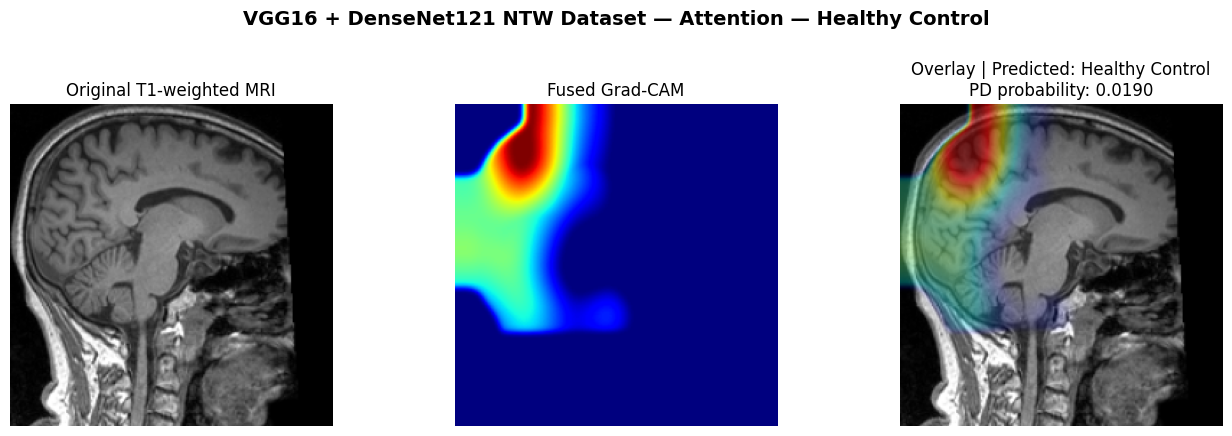

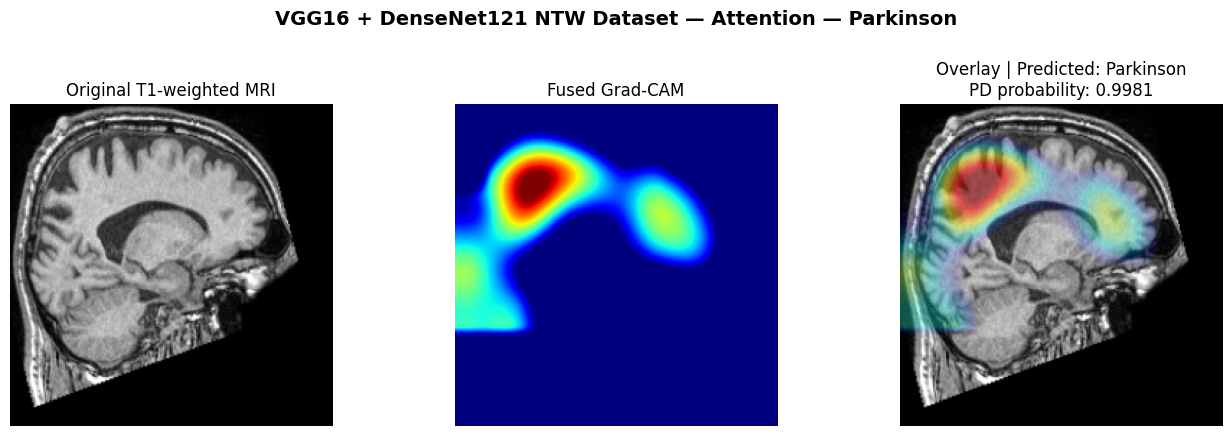

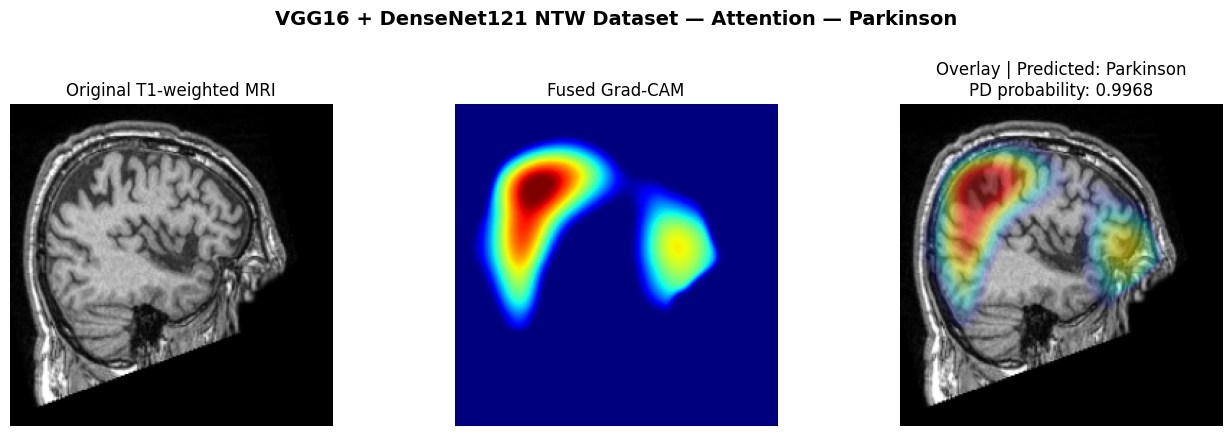

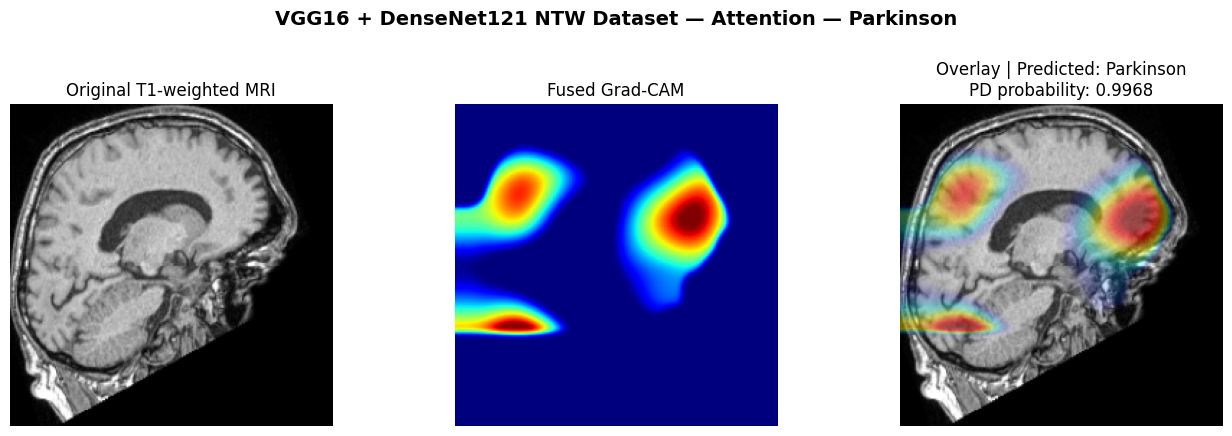

,Model,Evaluation_Level,Fusion_Type,Accuracy,Precision,Recall,Specificity,F1_Score,ROC_AUC,TN,FP,FN,TP,Evaluation_Samples
0,VGG16_DenseNet121_concatenation_NTW,Image-Level,concatenation,0.939759,0.906452,0.996454,0.865741,0.949324,0.994205,187,29,1,281,498
1,VGG16_DenseNet121_attention_NTW,Image-Level,attention,0.748996,0.703896,0.960993,0.472222,0.812594,0.892419,102,114,11,271,498


Completed. Results saved in: /content/drive/MyDrive/NTW_dataset_projects_files_for_parkinson/Early_fusion_of_NTW_dataset/Early_fusion_image_level/VGG16_Denesenet_image_level_data_save_here_2


In [ ]:
all_metrics = []

for fusion_type in FUSION_METHODS:
    print("\n" + "=" * 80)
    print(
        "Training VGG16 + DenseNet121 "
        f"{fusion_type.title()} Fusion"
    )
    print("=" * 80)

    trained_model, run_folders, file_prefix = (
        train_fusion_method(fusion_type)
    )

    # Example: Adjusting parameters for create_brain_mask
    # You can experiment with these values to 'correct' the Grad-CAM images
    custom_gradcam_params = {
        "threshold_percentile": 20,  # Example: Higher threshold for foreground detection
        "face_neck_crop_ratio": 0.75, # Example: Crop less from the face/neck region
        "erosion_size_factor": 0.06, # Example: Slightly more erosion
        "gaussian_blur_kernel": (17, 17) # Example: Stronger blur for softer edges
    }

    method_metrics = evaluate_model(
        trained_model,
        fusion_type,
        run_folders,
        file_prefix,
        # Pass custom parameters for Grad-CAM generation
        **custom_gradcam_params,
    )

    all_metrics.append(method_metrics)

    # Free GPU memory before the next model
    del trained_model
    tf.keras.backend.clear_session()

comparison_frame = pd.DataFrame(all_metrics)
display(comparison_frame)

comparison_frame.to_csv(
    Path(SAVE_DIR)
    / "VGG16_DenseNet121_Concatenation_vs_Attention.csv",
    index=False,
)

print("Completed. Results saved in:", SAVE_DIR)
